In [1]:
# This is a refactored notebook sent to Chase

In [1]:
# Code for improving the Y-M relation with clusters from MillenniumTNG simulations.
# This notebook-style script has three parts:
# 1) Build physically motivated summary quantities from radial profiles.
# 2) Compare analytic and ML-based mass predictors.
# 3) Explore hydrostatic-equilibrium (HSE) mass estimates.

In [1]:
import numpy as np
import os
import matplotlib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from scipy.optimize import curve_fit
%matplotlib inline

# Plot style shared by all figures in this notebook.
font = {"size": 14, "family": "STIXGeneral"}
matplotlib.rc('font', **font)
matplotlib.rc('axes', labelsize=16) 
plt.rcParams['legend.fontsize']=14
plt.rcParams["figure.figsize"] = [6.0,4.]
# plt.rcParams["xtick.labelsize"] = 16; plt.rcParams["ytick.labelsize"] = 16
matplotlib.rc('text', usetex=True)

plt.rcParams["figure.figsize"] = (5, 3)
plt.rcParams["axes.grid"]=True;plt.rcParams["grid.alpha"]=0.4; plt.rcParams["grid.color"]='#999999'; plt.rcParams["grid.linestyle"]='--'

In [3]:
# Cumulative profile calculation from density profiles

# Define radial bin edges and calculate corresponding shell volumes
rbin_edges = np.append(0, np.geomspace(0.03, 2.5, num=128))  # [Mpc] - Radial bin edges
r_bins = 0.5 * (rbin_edges[1:] + rbin_edges[:-1])            # Bin centers
vol_bin = (4.0 / 3.0) * np.pi * (rbin_edges[1:]**3 - rbin_edges[:-1]**3)  # [Mpc^3] - Shell volumes

# Reused bin indices in Leander's 128-bin profile convention.
# 101 corresponds to approximately R200c and 81 to a smaller inner aperture.
INNER_BIN_IDX = 81
R200_BIN_IDX = 101

def cumulative_profile(profiles_in, r200):
    """
    Computes cumulative (integrated) mass profiles from 3D density profiles.
    
    Parameters
    ----------
    profiles_in : np.ndarray
        Input density profiles of shape (N_halos, N_bins).
    r200 : np.ndarray
        Array of r200 (halo radius) values for each halo.
        
    Returns
    -------
    cum_profiles : np.ndarray
        Cumulative mass profiles of shape (N_halos, N_bins). 
    """
    profiles = profiles_in.copy()
    num_halos, num_bins = profiles.shape

    # Rescale profiles with r200 and bin volume
    profiles *= (r200[:, np.newaxis] ** 3) * vol_bin[np.newaxis, :] # Results in matrix of shape (N_halos, N_bins)
    
    # Calculate cumulative sum along radial bins
    cum_profiles = np.zeros((num_halos, num_bins))
    cum_profiles[:, 0] = profiles[:, 0]
    for i in range(1, num_bins):
        cum_profiles[:, i] = cum_profiles[:, i - 1] + profiles[:, i] 
    
    return cum_profiles # cum_profiles[h, i] = Total mass enclosed within outer edge of bin i for halo h.

In [4]:
# Setting path to the data and the plot directory
# dire = working directory where MTNG data files live (e.g. Raw/grp_*.bin)
# os.chdir(dire) = set Python's current working directory to that folder

# Windows: use forward slashes (Python accepts them) or raw string r'C:\...'
dire = r'/mnt/c/Users/cenlo/Desktop/scatter_proj/MTNG_data/z=0.5/' # Note: Using WSL pathing due to WSL runnign kernel
os.chdir(dire)

In [5]:
redshift_2nd_catalog = 0.5 # Redshift of the 2nd catalog

# Create array of concatenated (E(z), 1)
Ez=np.sqrt(.3089*(1+redshift_2nd_catalog)**3 + 1. - .3089) # Model without radiation (fair assumption for z < 5): E(z) = H(z)/H_0 = sqrt( Omega_m(1+z)^3 + Omega_Lambda ) = sqrt( Omega_m*(1+z)^3 + (1 - Omega_m) )
mask=np.arange(37371+31649)<31649; Ez=np.ones(37371+31649)*Ez; Ez[~mask]=1. # Split catalogs into first 31649 and next 37371. For second group of 37371, set E(z) to 1
z = np.zeros_like(Ez); z[mask] = redshift_2nd_catalog # Split catalog into first 31649 and next 37371. For first group of 37371, set z to second catalog. Leave second group as z=0



powlaw=np.logspace(-10,30,num=5);
XH=0.76; # H mass fraction
MASS_CUT = 5e3

# Scaling Y from Leander's files
# (kpc/Mpc)^2 * sigma_T / (me * c^2) * 1e10msun/h / Gyr^2
Y_scaling = 1e-6 * (6.65e-25) / (9.1e-28 * 3e10**2) * 1.98e43/0.6774 / (3.154e16)**2

# Scaling y from Leander's files
# (kpc/Mpc)^2 * sigma_T / (me * c^2) * 1e10msun/h / Gyr^2
y_scaling = 1e-6 * (6.65e-25) / (9.1e-28 * 3e10**2) * 1.98e43/0.6774 / (3.154e16)**2 

# Scaling ne from Leander's files
# m_proton / (1e10Msun/h) * 2/(1+XH) [which corresponds to ne->rho_gas/mp]
rho_scaling = 2 * 1.6726219e-24 / (1.98e43/0.6774) / (1+XH)

In [6]:
Y200 = np.load('Y200c.npy')
m200 = np.load('M200c.npy')
# pos = np.load('GroupPos.npy')
r200 = np.load('R200c.npy'); #r500 = np.load('LessImp/R500c.npy')
T500 = np.load('T500c.npy')

# See the raw data section below if you want any more data from group catalog of MTNG

In [7]:
yProf_original = np.load('y_profiles.npy'); 
neProf = np.load('ne_profiles.npy'); # units: 1e10 Msun/ Mpc^3
mStarProf = np.load('mStar_profiles.npy'); # units: 1e10 Msun/ Mpc^3
#concNFW = np.load('Conc_Rockstar.npy');

In [8]:

os.chdir(r'/mnt/c/Users/cenlo/Desktop/scatter_proj/MTNG_data/z=0.0/')


m200=np.concatenate((m200,np.load('M200c.npy')),axis=0)
m200=m200*Ez**(2/5.)

r200=np.concatenate((r200,np.load('R200c.npy')),axis=0)
#r500=np.concatenate((r500,np.load('LessImp/R500c.npy')),axis=0)
# concNFW=np.concatenate((concNFW,np.load('Conc_Rockstar.npy')),axis=0)
Y200=np.concatenate((Y200,np.load('Y200c.npy')),axis=0)
neProf=np.concatenate((neProf,np.load('ne_profiles.npy')),axis=0);
mStarProf=np.concatenate((mStarProf,np.load('mStar_profiles.npy')),axis=0); 
yProf_original=np.concatenate((yProf_original,np.load('y_profiles.npy')),axis=0);
# pos=np.concatenate((pos,np.load('GroupPos.npy')),axis=0)
os.chdir(dire)

In [9]:
Y200 *= Y_scaling
neProf *= rho_scaling
yProf = yProf_original * y_scaling

In [10]:
Y_r = cumulative_profile(yProf,r200)
mGas_r = cumulative_profile(neProf,r200)
mStar_r = cumulative_profile(mStarProf,r200)
#conc = r200/r500
GasConc = mGas_r[:, INNER_BIN_IDX] / mGas_r[:, R200_BIN_IDX]
mGas = mGas_r[:, R200_BIN_IDX]  # Gas mass integrated to R200c
mStar = mStar_r[:, R200_BIN_IDX]
MYratio = m200*1e10/(Y200**(3./5.)*1.234852304e9)
YConc = Y_r[:, INNER_BIN_IDX] / Y_r[:, R200_BIN_IDX]

In [11]:
# Use a higher mass cutoff to focus on high-mass halos
# which are the targets of this study

redshift_cut = False

if redshift_cut == True:
    mask = (m200 > MASS_CUT) * (z >= 0.2)
else:
    mask = (m200 > MASS_CUT)
zH = z[mask]
m200H=m200[mask];
Y200H=Y200[mask]; mGasH=mGas[mask]; 
GasConcH=GasConc[mask]; YConcH=YConc[mask]; 
# concNFWS=concNFW[mask]; 
mStarH=mStar[mask];

# EzS=Ez[mask]; #r200=r200[mask]; posS=pos[mask]; #GasConc2S=GasConc2[mask];

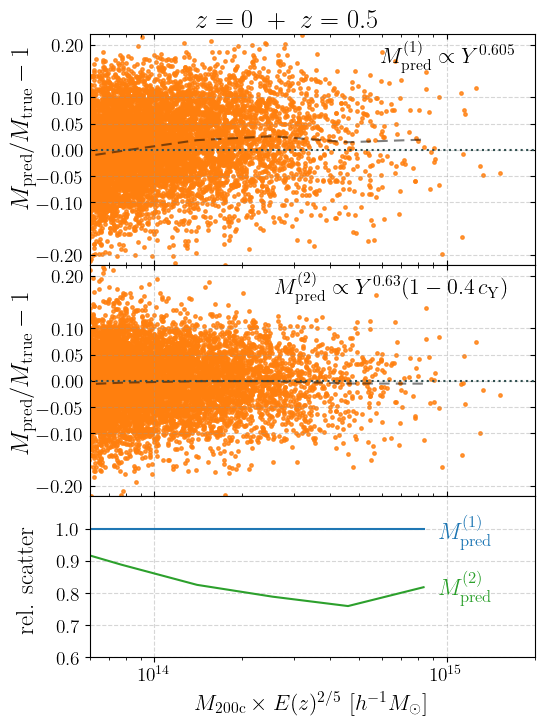

In [12]:
# Similar plot to Fig. 9 in the old paper
# only using z=0.5

mRatio = {}; stdM={}
numEqs = 2
mRatio[0] = (Y200H**(.605)*2e17)/(m200H*1e10)-1.
mRatio[1] = (Y200H**(.61)*2.7e17*(1.-.4*YConcH))/(m200H*1e10)-1.

temp=np.logspace(3.5,5.05,num=7);
meanM=np.zeros((numEqs,len(temp)-1)); temp2=np.zeros(len(temp)-1)
xbins=np.sqrt(temp[:-1]*temp[1:]);
for j in range(numEqs):
    for i in range(len(temp)-1):
        mask=(m200H>=temp[i])*(m200H<=temp[i+1])
        meanM[j,i]=np.mean(mRatio[j][mask]); temp2[i]=np.std(np.log(1+mRatio[j][mask]));
    stdM[j]=temp2.copy()

fig = plt.figure(num=None, figsize=(5.3, 7))
fig.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)

ax1 = fig.add_axes([0.15, 0.66, 0.84, 0.33], xlim=(6e13,2e15),ylim=(-0.22,0.22));
ax2 = fig.add_axes([0.15, 0.33, 0.84, 0.33], xlim=(6e13,2e15),ylim=(-0.22,0.22)); 
ax3 = fig.add_axes([0.15, 0.1, 0.84, 0.23], xlim=(6e13,2e15),ylim=(0.6,1.1)); 

ax1.set_yscale('linear'); ax1.set_xscale('log');
ax2.set_yscale('linear'); ax2.set_xscale('log'); 
ax1.set_yticks((-0.2,-0.1,-0.05,0,0.05,0.1,0.2));
ax2.set_yticks((-0.2,-0.1,-0.05,0,0.05,0.1,0.2)); #ax2.set_xticklabels(('0.06','0.1','0.3','1','2'))
ax3.set_yticks((0.6,0.7,0.8,0.9,1));
ax1.scatter(m200H*1e10,mRatio[0],alpha=.8,s=6,color='C1')
ax1.plot(xbins*1e10,meanM[0],'--',color='black',alpha=0.5, dashes=[5, 3])
ax1.tick_params(axis="both",direction="in",which='both',right='true',top='true', labelbottom=0)
ax1.axhline(y=0, color='darkslategray',ls='dotted')

ax2.scatter(m200H*1e10,mRatio[1],alpha=.8,s=6,color='C1')
ax2.plot(xbins*1e10,meanM[1],'--',color='black',alpha=0.5, dashes=[5, 3])
ax2.tick_params(axis="both",direction="in",which='both',right='true',top='true')
ax2.axhline(y=0, color='darkslategray',ls='dotted')
ax3.semilogx(xbins*1e10,np.ones(len(xbins)))
ax3.semilogx(xbins*1e10,stdM[1]/stdM[0],color='C2')
#ax3.semilogx(pltSct*1e10,stdMRatio3/stdMRatio0,color='C3')


ax1.grid(visible=True, which='major', color='#999999', linestyle='--',alpha=0.4)
ax2.grid(visible=True, which='major', color='#999999', linestyle='--',alpha=0.4)
ax3.grid(visible=True, which='major', color='#999999', linestyle='--',alpha=0.4)

fig.text(0.7, 0.95, r"$M^{(1)}_\mathrm{pred}\propto Y^{0.605}$", rotation=0,fontsize=16)
fig.text(0.5, 0.62, r"$M^{(2)}_\mathrm{pred}\propto Y^{0.63} (1-0.4\, c_\mathrm{Y})$", rotation=0,fontsize=16)
fig.text(0.0, 0.75, r"$M_\mathrm{pred}/M_\mathrm{true} -1$", rotation=90,fontsize=18)
fig.text(0.0, 0.4, r"$M_\mathrm{pred}/M_\mathrm{true} -1$", rotation=90,fontsize=18)
fig.text(0.01, 0.14, r"rel. scatter", rotation=90,fontsize=18)
fig.text(0.81, 0.27, r"$M^{(1)}_\mathrm{pred}$",fontsize=17,color='C0')


if redshift_cut == True:
    fig.text(0.81, 0.13, r"$M^{(2)}_\mathrm{pred}$",fontsize=17, color='C2')
    plt.xlabel(r'$ M_\mathrm{200c} \times E(z)^{2/5}\ [h^{-1} M_\odot]$');
    fig.text(0.35, 1, r'$z=0.5 (z  > 0.2)$', fontsize=19)
else:
    fig.text(0.81, 0.19, r"$M^{(2)}_\mathrm{pred}$",fontsize=17, color='C2')
    plt.xlabel(r'$ M_\mathrm{200c} \times E(z)^{2/5}\ [h^{-1} M_\odot]$');
    fig.text(0.35, 1, r'$z=0 \ +\ z=0.5$', fontsize=19)
# plt.savefig(plotdir+'trash.png', bbox_inches='tight', dpi=150)

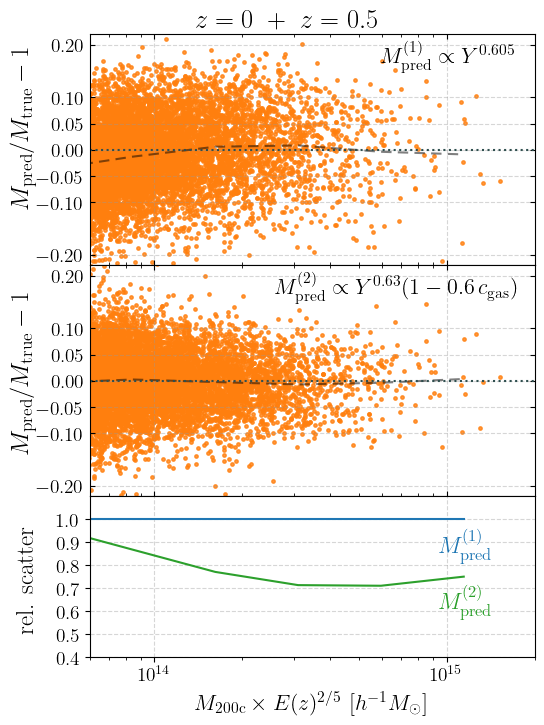

In [13]:
# Similar plot to Fig. 9 in the old paper
# only using z=0.5

mRatio = {}; stdM={}
numEqs = 2
mRatio[0] = (Y200H**(.605)*1.97e17)/(m200H*1e10)-1.
mRatio[1] = (Y200H**(.625)*3.41e17*(1.-.6*GasConcH))/(m200H*1e10)-1.

temp=np.logspace(3.5,5.2,num=7);
meanM=np.zeros((numEqs,len(temp)-1)); temp2=np.zeros(len(temp)-1)
xbins=np.sqrt(temp[:-1]*temp[1:]);
for j in range(numEqs):
    for i in range(len(temp)-1):
        mask=(m200H>=temp[i])*(m200H<=temp[i+1])
        meanM[j,i]=np.mean(mRatio[j][mask]); temp2[i]=np.std(np.log(1+mRatio[j][mask]));
    stdM[j]=temp2.copy()

fig = plt.figure(num=None, figsize=(5.3, 7))
fig.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)

ax1 = fig.add_axes([0.15, 0.66, 0.84, 0.33], xlim=(6e13,2e15),ylim=(-0.22,0.22));
ax2 = fig.add_axes([0.15, 0.33, 0.84, 0.33], xlim=(6e13,2e15),ylim=(-0.22,0.22)); 
ax3 = fig.add_axes([0.15, 0.1, 0.84, 0.23], xlim=(6e13,2e15),ylim=(0.4,1.1)); 

ax1.set_yscale('linear'); ax1.set_xscale('log');
ax2.set_yscale('linear'); ax2.set_xscale('log'); 
ax1.set_yticks((-0.2,-0.1,-0.05,0,0.05,0.1,0.2));
ax2.set_yticks((-0.2,-0.1,-0.05,0,0.05,0.1,0.2)); #ax2.set_xticklabels(('0.06','0.1','0.3','1','2'))
ax3.set_yticks((0.4,0.5,0.6,0.7,0.8,0.9,1));
ax1.scatter(m200H*1e10,mRatio[0],alpha=.8,s=6,color='C1')
ax1.plot(xbins*1e10,meanM[0],'--',color='black',alpha=0.5, dashes=[5, 3])
ax1.tick_params(axis="both",direction="in",which='both',right='true',top='true', labelbottom=0)
ax1.axhline(y=0, color='darkslategray',ls='dotted')

ax2.scatter(m200H*1e10,mRatio[1],alpha=.8,s=6,color='C1')
ax2.plot(xbins*1e10,meanM[1],'--',color='black',alpha=0.5, dashes=[5, 3])
ax2.tick_params(axis="both",direction="in",which='both',right='true',top='true')
ax2.axhline(y=0, color='darkslategray',ls='dotted')
ax3.semilogx(xbins*1e10,np.ones(len(xbins)))
ax3.semilogx(xbins*1e10,stdM[1]/stdM[0],color='C2')
#ax3.semilogx(pltSct*1e10,stdMRatio3/stdMRatio0,color='C3')

ax1.grid(visible=True, which='major', color='#999999', linestyle='--',alpha=0.4)
ax2.grid(visible=True, which='major', color='#999999', linestyle='--',alpha=0.4)
ax3.grid(visible=True, which='major', color='#999999', linestyle='--',alpha=0.4)

# Use raw strings (r"...") for all LaTeX/math-formatted strings to avoid invalid escape sequence warnings
fig.text(0.7, 0.95, r"$M^{(1)}_\mathrm{pred}\propto Y^{0.605}$", rotation=0,fontsize=16)
fig.text(0.5, 0.62, r"$M^{(2)}_\mathrm{pred}\propto Y^{0.63} (1-0.6\, c_\mathrm{gas})$", rotation=0,fontsize=16)
fig.text(0.0, 0.75, r"$M_\mathrm{pred}/M_\mathrm{true} -1$", rotation=90,fontsize=18)
fig.text(0.0, 0.4, r"$M_\mathrm{pred}/M_\mathrm{true} -1$", rotation=90,fontsize=18)
fig.text(0.01, 0.14, r"rel. scatter", rotation=90,fontsize=18)
fig.text(0.81, 0.25, r"$M^{(1)}_\mathrm{pred}$",fontsize=17, color='C0')


if redshift_cut == True:
    fig.text(0.81, 0.13, r"$M^{(2)}_\mathrm{pred}$",fontsize=17, color='C2')
    plt.xlabel(r'$ M_\mathrm{200c} \times E(z)^{2/5}\ [h^{-1} M_\odot]$')
    fig.text(0.35, 1, r'$z=0.5 (z > 0.2)$', fontsize=19)
else:
    fig.text(0.81, 0.17, r"$M^{(2)}_\mathrm{pred}$",fontsize=17, color='C2')
    plt.xlabel(r'$ M_\mathrm{200c} \times E(z)^{2/5}\ [h^{-1} M_\odot]$')
    fig.text(0.35, 1, r'$z=0 \ +\ z=0.5$', fontsize=19)
# plt.savefig(plotdir+'trash.png', bbox_inches='tight', dpi=150)

## Using RF to reduce the scatter

In [14]:
# We add more parameters to predict the mass more accurately

In [15]:
# Temporary random split (50/50) for a quick RF benchmark.
# A fixed RNG seed keeps the split reproducible for students.
rng = np.random.default_rng(0)
maskTest = rng.choice([True, False], size=len(m200H), p=[0.5, 0.5]) # Define test set
# Y200S = Y200[maskTest]; m200S=m200[maskTest]

In [16]:
# Input array to RF
inp=np.zeros((len(m200H),5))
inp[:,0]=Y200H; 
inp[:,1]=YConcH;
inp[:,2]=mStarH/mGasH;
# inp[:,2]=GasConc;
#inp[:,4]=nGal
out=m200H*1e10/(Y200H**(3./5.)*1.97e17)

In [17]:
inp[:, :0]

array([], shape=(10546, 0), dtype=float64)

In [18]:
#Initializing RF
regr_YCpara = RandomForestRegressor(max_depth=50, random_state=0,min_samples_leaf=5,n_estimators=50,n_jobs=-1)
regr_YMpara = RandomForestRegressor(max_depth=50, random_state=0,min_samples_leaf=5,n_estimators=50,n_jobs=-1)
regr_3para = RandomForestRegressor(max_depth=50, random_state=0,min_samples_leaf=5,n_estimators=50,n_jobs=-1)

#Fitting to training data
regr_YCpara.fit(inp[~maskTest, :2],out[~maskTest],sample_weight=pow(m200H,1)[~maskTest])
regr_YMpara.fit(inp[~maskTest][:, [0,2]],out[~maskTest],sample_weight=pow(m200H,1)[~maskTest])
regr_3para.fit(inp[~maskTest],out[~maskTest],sample_weight=pow(m200H,1)[~maskTest])

#Importance given by RF to each feature
print(regr_YCpara.feature_importances_)
print(regr_YMpara.feature_importances_)
print(regr_3para.feature_importances_)

print('2-parameter RF:', metrics.mean_squared_error(regr_YCpara.predict(inp[maskTest, :2]),out[maskTest]))
print('2-parameter RF:', metrics.mean_squared_error(regr_YMpara.predict(inp[maskTest][:, [0,2]]),out[maskTest]))
print('3-parameter RF:', metrics.mean_squared_error(regr_3para.predict(inp[maskTest]),out[maskTest]))

[0.30907756 0.69092244]
[0.38933577 0.61066423]
[0.21466786 0.51576949 0.26956265 0.         0.        ]
2-parameter RF: 0.0031361717215524815
2-parameter RF: 0.0030787981152579766
3-parameter RF: 0.0024508707375925686


In [19]:
# Null test: training a RF only on Y
regr_Y_only = RandomForestRegressor(max_depth=50, random_state=0,min_samples_leaf=5,n_estimators=50,n_jobs=-1)
regr_Y_only.fit(inp[~maskTest][:,0].reshape(-1,1),out[~maskTest],sample_weight=pow(m200H,1.)[~maskTest]);

print('Y-only RF:', metrics.mean_squared_error(regr_Y_only.predict(inp[maskTest][:,0].reshape(-1,1)),out[maskTest]))

Y-only RF: 0.004198751117775567


In [20]:
# TODO create a RF feature importance plot.

In [21]:
mRatio_Y_only = regr_Y_only.predict(inp[maskTest][:,0].reshape(-1,1))/out[maskTest]-1;
mRatio_YCpara = regr_YCpara.predict(inp[maskTest, :2])/out[maskTest]-1;
mRatio_YMpara = regr_YMpara.predict(inp[maskTest][:, [0,2]])/out[maskTest]-1;
mRatio_3para = regr_3para.predict(inp[maskTest])/out[maskTest]-1;


temp=np.logspace(3.6,4.7,num=7);temp2=np.sqrt(temp[:-1]*temp[1:]); 
stdM_Y_only = np.zeros(len(temp)-1); stdM_YCpara = stdM_Y_only.copy(); stdM_YMpara = stdM_Y_only.copy(); stdM_3para = stdM_Y_only.copy()

for i in range(len(temp)-1): # Compute std for each run in mass bins defined by 'temp = np.logspace..'
    mask=(m200H[maskTest]>=temp[i])*(m200H[maskTest]<=temp[i+1])
    stdM_Y_only[i]=np.std(mRatio_Y_only[mask]); 
    stdM_YCpara[i]=np.std(mRatio_YCpara[mask]);
    stdM_YMpara[i]=np.std(mRatio_YMpara[mask]);
    stdM_3para[i]=np.std(mRatio_3para[mask]);


if redshift_cut == False:
    zH_test = zH[maskTest]
    is_z0  = (zH_test < 0.1)    # z=0 catalogue
    is_z05 = (zH_test >= 0.1)   # z=0.5 catalogue   
    stdM_Y_only_z0 = np.zeros(len(temp)-1); stdM_Y_only_z05 = np.zeros(len(temp)-1)
    stdM_Ycpara_z0 = np.zeros(len(temp)-1); stdM_Ycpara_z05 = np.zeros(len(temp)-1)
    stdM_YMpara_z0 = np.zeros(len(temp)-1); stdM_YMpara_z05 = np.zeros(len(temp)-1)
    stdM_3para_z0  = np.zeros(len(temp)-1); stdM_3para_z05  = np.zeros(len(temp)-1)

    for i in range(len(temp)-1):
        base_mask = (m200H[maskTest] >= temp[i]) * (m200H[maskTest] <= temp[i+1])
        
        m0 = base_mask & is_z0
        m5 = base_mask & is_z05
        
        if m0.sum() > 3:
            stdM_Y_only_z0[i] = np.std(mRatio_Y_only[m0])
            stdM_Ycpara_z0[i] = np.std(mRatio_YCpara[m0])
            stdM_YMpara_z0[i] = np.std(mRatio_YMpara[m0])
            stdM_3para_z0[i]  = np.std(mRatio_3para[m0])
        if m5.sum() > 3:
            stdM_Y_only_z05[i] = np.std(mRatio_Y_only[m5])
            stdM_Ycpara_z05[i] = np.std(mRatio_YCpara[m5])
            stdM_YMpara_z05[i] = np.std(mRatio_YMpara[m5])
            stdM_3para_z05[i]  = np.std(mRatio_3para[m5])

#### Plot single RF set, with 1 or 2 catalogue handling

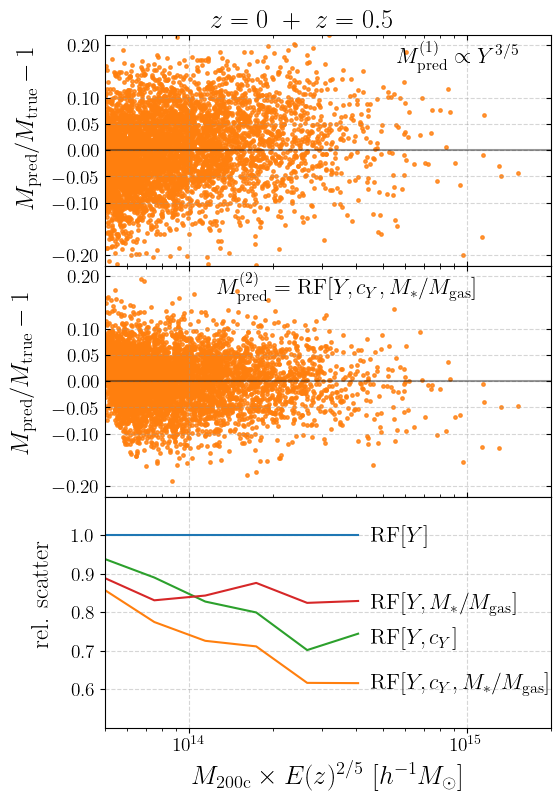

In [22]:
fig = plt.figure(num=None, figsize=(5.3, 7))
fig.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)

ax1 = fig.add_axes([0.15, 0.66, 0.84, 0.33], xlim=(5e13,2e15), ylim=(-0.22,0.22))
ax2 = fig.add_axes([0.15, 0.33, 0.84, 0.33], xlim=(5e13,2e15), ylim=(-0.22,0.22))
ax3 = fig.add_axes([0.15, 0.0, 0.84, 0.33], xlim=(5e13,2e15), ylim=(0.5,1.1))

ax1.set_yscale('linear')
ax1.set_xscale('log')
ax2.set_yscale('linear')
ax2.set_xscale('log')
ax1.set_yticks([-0.2, -0.1, -0.05, 0, 0.05, 0.1, 0.2])
ax2.set_yticks([-0.2, -0.1, -0.05, 0, 0.05, 0.1, 0.2])  # ax2.set_xticklabels(('0.06','0.1','0.3','1','2'))
ax3.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax1.scatter(m200H[maskTest]*1e10, (Y200H[maskTest]**(.605)*2e17)/(m200H[maskTest]*1e10)-1., alpha=.8, s=6, color='C1')
ax1.tick_params(axis="both", direction="in", which='both', right=True, top=True, labelbottom=0)
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.4)

ax2.scatter(m200H[maskTest]*1e10, mRatio_3para, alpha=.8, s=6, color='C1')
ax2.tick_params(axis="both", direction="in", which='both', right=True, top=True, labelbottom=0)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.4)
ax3.semilogx(temp2*1e10, np.ones(len(temp2)))
ax3.semilogx(temp2*1e10, stdM_3para/stdM_Y_only)
ax3.semilogx(temp2*1e10, stdM_YCpara/stdM_Y_only)
ax3.semilogx(temp2*1e10, stdM_YMpara/stdM_Y_only)

# ax3.semilogx(temp2*1e10, stdM3/stdM0)
# ax3.legend(["RF[$Y$]", "RF[$Y,c_\mathrm{gas}$]", "RF[$Y,c_\mathrm{gas},M_*/M_\mathrm{gas}$]", "RF[$Y,c_\mathrm{gas},M_*/M_\mathrm{gas},c_{\,\mathrm{DM}}$]"], loc=2, fontsize=15)

fig.text(0.7, 0.95, r"$M^{(1)}_\mathrm{pred}\propto Y^{3/5}$", rotation=0, fontsize=16)
fig.text(0.36, 0.62, r"$M^{(2)}_\mathrm{pred}=\mathrm{RF}[Y,c_{Y},M_*/M_\mathrm{gas}]$",
          rotation=0, fontsize=16)
fig.text(-0.02, 0.75, r"$M_\mathrm{pred}/M_\mathrm{true} -1$", rotation=90, fontsize=18)
fig.text(-0.03, 0.4, r"$M_\mathrm{pred}/M_\mathrm{true} -1$", rotation=90, fontsize=18)
fig.text(0.01, 0.12, r"rel. scatter", rotation=90, fontsize=18)

if redshift_cut == True:
    fig.text(0.65, 0.265, r"RF[$Y$]", fontsize=16)
    fig.text(0.65, 0.16, r"RF[$Y,c_Y$]", fontsize=16)
    fig.text(0.65, 0.22, r"RF[$Y,M_*/M_\mathrm{gas}$]", fontsize=16)
    # fig.text(0.62, 0.11, r"RF[$Y,c_\mathrm{gas},M_*/M_\mathrm{gas}$]", fontsize=16)
    fig.text(0.65, 0.09, r"RF[$Y,c_{Y},M_*/M_\mathrm{gas}$]", fontsize=16)
    plt.xlabel(r'$M_\mathrm{200c} \times E(z)^{2/5}\ [h^{-1} M_\odot]$', fontsize=19)
    # fig.text(0.35, 1, r'$z=0.5$', fontsize=19)
    fig.text(0.35, 1, r'$z=0.5 ( z > 0.2)$', fontsize=19)
    # plt.savefig(plotdir+'trash.pdf', bbox_inches='tight')
else:
    fig.text(0.65, 0.265, r"RF[$Y$]", fontsize=16)
    fig.text(0.65, 0.12, r"RF[$Y,c_Y$]", fontsize=16)
    fig.text(0.65, 0.17, r"RF[$Y,M_*/M_\mathrm{gas}$]", fontsize=16)
    # fig.text(0.62, 0.11, r"RF[$Y,c_\mathrm{gas},M_*/M_\mathrm{gas}$]", fontsize=16)
    fig.text(0.65, 0.055, r"RF[$Y,c_{Y},M_*/M_\mathrm{gas}$]", fontsize=16)
    plt.xlabel(r'$M_\mathrm{200c} \times E(z)^{2/5}\ [h^{-1} M_\odot]$', fontsize=19)
    # fig.text(0.35, 1, r'$z=0.5$', fontsize=19)
    fig.text(0.35, 1, r'$z=0 \ +\ z=0.5$', fontsize=19)
    